In [4]:
import numpy, matplotlib, sklearn
print('All libraries OK')

All libraries OK


# STEP 1 :
## IMPORT LIBRARIES

# Step 1: Environment Setup and Directory Structure

## Objective
Initialize the project environment by:
1. Verifying the working directory
2. Creating required directory structure for data, models, and plots
3. Confirming all dependencies are properly installed

## Expected Output
- `data/` directory for storing `.npy` files
- `models/` directory for saving trained models
- `plots/` directory for visualization outputs
- Version confirmation of key packages (TensorFlow, NumPy)

## Why This Matters
- **Separation of concerns**: Each directory serves a specific purpose in the pipeline
- **Reproducibility**: Confirming versions ensures consistent behavior across environments
- **Clean engineering**: Organized structure makes the project maintainable and defensible

## Next Steps
After successful execution, proceed to Step 2 (Data Preparation)

In [5]:
# ============================================
# STEP 1: ENVIRONMENT SETUP & DIRECTORY CREATION
# ============================================

# Import required libraries
import os
import sys

# Print current working directory
print("=" * 60)
print("ENVIRONMENT SETUP")
print("=" * 60)
print(f"Working directory: {os.getcwd()}")

# Create required directories if they don't exist
print("\n[1/3] Creating directory structure...")
required_dirs = ["data", "models", "plots"]

for dir_name in required_dirs:
    if not os.path.exists(dir_name):
        os.makedirs(dir_name)
        print(f"  ✓ Created: {dir_name}/")
    else:
        print(f"  ✓ Already exists: {dir_name}/")

# Verify directory structure
print("\n[2/3] Verifying directory structure...")
project_contents = os.listdir(".")
print(f"  Current directory contents: {project_contents}")

# Check key package versions
print("\n[3/3] Verifying package installations...")

try:
    import numpy as np
    print(f"  ✓ NumPy version: {np.__version__}")
except ImportError:
    print("  ✗ NumPy NOT installed")

try:
    import tensorflow as tf
    print(f"  ✓ TensorFlow version: {tf.__version__}")
except ImportError:
    print("  ✗ TensorFlow NOT installed")

try:
    import matplotlib
    print(f"  ✓ Matplotlib version: {matplotlib.__version__}")
except ImportError:
    print("  ✗ Matplotlib NOT installed")

try:
    import sklearn
    print(f"  ✓ Scikit-learn version: {sklearn.__version__}")
except ImportError:
    print("  ✗ Scikit-learn NOT installed")

try:
    import medmnist
    print(f"  ✓ MedMNIST version: {medmnist.__version__}")
except ImportError:
    print("  ✗ MedMNIST NOT installed")

try:
    import pandas as pd
    print(f"  ✓ Pandas version: {pd.__version__}")
except ImportError:
    print("  ✗ Pandas NOT installed")

# Final summary
print("\n" + "=" * 60)
print("ENVIRONMENT SETUP COMPLETE ✓")
print("=" * 60)
print("\nReady to proceed to Step 2: Data Preparation")

ENVIRONMENT SETUP
Working directory: C:\Users\the eye informatique\Desktop\AI\cnn-pneumonia-medmnist

[1/3] Creating directory structure...
  ✓ Already exists: data/
  ✓ Already exists: models/
  ✓ Already exists: plots/

[2/3] Verifying directory structure...
  Current directory contents: ['.ipynb_checkpoints', '.virtual_documents', 'data', 'models', 'plots', 'Untitled.ipynb', 'venv']

[3/3] Verifying package installations...
  ✓ NumPy version: 1.26.4
  ✓ TensorFlow version: 2.21.0
  ✓ Matplotlib version: 3.9.2
  ✓ Scikit-learn version: 1.9.0
  ✗ MedMNIST NOT installed
  ✓ Pandas version: 2.3.3

ENVIRONMENT SETUP COMPLETE ✓

Ready to proceed to Step 2: Data Preparation


# Step 1.5: Install MedMNIST

## Issue Detected
MedMNIST package is not installed in the Jupyter environment, even though it was installed via pip earlier. This can happen when Jupyter uses a different Python kernel.

## Solution
Install MedMNIST directly from within Jupyter Notebook to ensure it's available in the current kernel.

## Why This Matters
- MedMNIST provides easy access to the PneumoniaMNIST dataset
- Required for data preparation in Step 2
- Ensures the correct kernel has all dependencies

In [6]:
# ============================================
# STEP 1.5: INSTALL MEDMNIST IN JUPYTER KERNEL
# ============================================

import sys
import subprocess

print("=" * 60)
print("INSTALLING MEDMNIST")
print("=" * 60)

# Install medmnist using pip within the Jupyter environment
print("\n[1/2] Installing medmnist package...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "medmnist", "-q"])

# Verify installation
print("\n[2/2] Verifying installation...")
try:
    import medmnist
    print(f"  ✓ MedMNIST version: {medmnist.__version__}")
    print(f"  ✓ Installation location: {medmnist.__file__}")
except ImportError:
    print("  ✗ MedMNIST installation failed")

print("\n" + "=" * 60)
print("MEDMNIST INSTALLATION COMPLETE ✓")
print("=" * 60)
print("\nReady to proceed to Step 2: Data Preparation")

INSTALLING MEDMNIST

[1/2] Installing medmnist package...

[2/2] Verifying installation...
  ✓ MedMNIST version: 3.0.2
  ✓ Installation location: C:\Users\the eye informatique\anaconda3\New folder\Lib\site-packages\medmnist\__init__.py

MEDMNIST INSTALLATION COMPLETE ✓

Ready to proceed to Step 2: Data Preparation


# Step 2: Data Preparation - Loading and Inspecting Dataset

## Objective
Load the PneumoniaMNIST dataset and inspect its core properties to understand the data structure before preprocessing.

## Key Inspections
- Image dimensions and channel count
- Dataset split sizes (train/validation/test)
- Pixel value range and data type
- Label structure and class distribution

## Why This Matters
Understanding the raw dataset properties is essential before designing the CNN architecture. Specifically, class distribution analysis helps us understand why recall (sensitivity) is prioritized over accuracy for pneumonia detection.

## Expected Outcome
Clear documentation of dataset statistics that will guide the normalization and model design decisions in subsequent steps.

In [7]:
import numpy as np
from medmnist import PneumoniaMNIST

np.random.seed(42)

print("=" * 60)
print("PNEUMONIAMNIST DATA PREPARATION")
print("=" * 60)

# Load dataset splits
print("\n[1/3] Loading PneumoniaMNIST dataset...")
train_dataset = PneumoniaMNIST(split="train", download=True)
val_dataset = PneumoniaMNIST(split="val", download=True)
test_dataset = PneumoniaMNIST(split="test", download=True)

X_train_raw = train_dataset.imgs
y_train_raw = train_dataset.labels
X_val_raw = val_dataset.imgs
y_val_raw = val_dataset.labels
X_test_raw = test_dataset.imgs
y_test_raw = test_dataset.labels

print("Dataset loaded successfully")

# Inspect dataset properties
print("\n[2/3] Dataset Inspection")
print("-" * 60)

print("Image Properties:")
print(f"  Dimensions: {X_train_raw.shape[1:3]}")
print(f"  Channels: {X_train_raw.shape[-1]}")
print(f"  Type: {'Grayscale' if X_train_raw.shape[-1] == 1 else 'RGB'}")

print("\nDataset Splits:")
print(f"  Training:   {X_train_raw.shape[0]:,} samples")
print(f"  Validation: {X_val_raw.shape[0]:,} samples")
print(f"  Test:       {X_test_raw.shape[0]:,} samples")

print("\nPixel Values:")
print(f"  Range: [{X_train_raw.min()}, {X_train_raw.max()}]")
print(f"  Dtype: {X_train_raw.dtype}")

print("\nLabel Structure:")
print(f"  Shape: {y_train_raw.shape}")
print(f"  Unique labels: {np.unique(y_train_raw)}")
print(f"  Dtype: {y_train_raw.dtype}")

print("\nClass Distribution (Training):")
unique, counts = np.unique(y_train_raw, return_counts=True)
for label, count in zip(unique, counts):
    percentage = (count / len(y_train_raw)) * 100
    class_name = "Pneumonia" if label == 1 else "Normal"
    print(f"  {class_name} ({label}): {count:,} samples ({percentage:.1f}%)")

# Data integrity check
print("\n[3/3] Data Integrity Check")
print("-" * 60)
print(f"  X_train: {X_train_raw.shape}")
print(f"  y_train: {y_train_raw.shape}")
print(f"  X_val:   {X_val_raw.shape}")
print(f"  y_val:   {y_val_raw.shape}")
print(f"  X_test:  {X_test_raw.shape}")
print(f"  y_test:  {y_test_raw.shape}")

print("\n" + "=" * 60)
print("DATA LOADING COMPLETE")
print("=" * 60)

PNEUMONIAMNIST DATA PREPARATION

[1/3] Loading PneumoniaMNIST dataset...


100%|██████████████████████████████████████████████████████████████████████████████| 4.17M/4.17M [00:21<00:00, 197kB/s]


Dataset loaded successfully

[2/3] Dataset Inspection
------------------------------------------------------------
Image Properties:
  Dimensions: (28, 28)
  Channels: 28
  Type: RGB

Dataset Splits:
  Training:   4,708 samples
  Validation: 524 samples
  Test:       624 samples

Pixel Values:
  Range: [0, 255]
  Dtype: uint8

Label Structure:
  Shape: (4708, 1)
  Unique labels: [0 1]
  Dtype: uint8

Class Distribution (Training):
  Normal (0): 1,214 samples (25.8%)
  Pneumonia (1): 3,494 samples (74.2%)

[3/3] Data Integrity Check
------------------------------------------------------------
  X_train: (4708, 28, 28)
  y_train: (4708, 1)
  X_val:   (524, 28, 28)
  y_val:   (524, 1)
  X_test:  (624, 28, 28)
  y_test:  (624, 1)

DATA LOADING COMPLETE


# Step 3: Data Normalization and Reshaping

## Objective
Transform the raw dataset into the format required for CNN training:
1. Reshape images to include the channel dimension (28, 28, 1)
2. Normalize pixel values from [0, 255] to [0, 1]
3. Convert labels to float32 for binary cross-entropy loss

## Why This Matters
- CNNs require explicit channel dimensions (even for grayscale)
- Normalization speeds up convergence and improves training stability
- Float32 is required for TensorFlow operations
- The test set must remain untouched during training

## Expected Output
- All arrays reshaped and normalized
- Pixel values in range [0, 1]
- Labels converted to float32
- Arrays ready for saving as .npy files

In [8]:
import numpy as np

print("=" * 60)
print("DATA NORMALIZATION AND RESHAPING")
print("=" * 60)

# Reshape images to add channel dimension
print("\n[1/3] Reshaping images to add channel dimension...")
X_train = X_train_raw.reshape(-1, 28, 28, 1)
X_val = X_val_raw.reshape(-1, 28, 28, 1)
X_test = X_test_raw.reshape(-1, 28, 28, 1)

print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")

# Normalize pixel values to [0, 1]
print("\n[2/3] Normalizing pixel values...")
X_train = X_train.astype(np.float32) / 255.0
X_val = X_val.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print(f"  Pixel range after normalization: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"  Dtype: {X_train.dtype}")

# Convert labels to float32
print("\n[3/3] Converting labels to float32...")
y_train = y_train_raw.astype(np.float32)
y_val = y_val_raw.astype(np.float32)
y_test = y_test_raw.astype(np.float32)

print(f"  y_train: {y_train.shape}, dtype: {y_train.dtype}")
print(f"  y_val:   {y_val.shape}, dtype: {y_val.dtype}")
print(f"  y_test:  {y_test.shape}, dtype: {y_test.dtype}")

print("\n" + "=" * 60)
print("NORMALIZATION COMPLETE")
print("=" * 60)

DATA NORMALIZATION AND RESHAPING

[1/3] Reshaping images to add channel dimension...
  X_train: (4708, 28, 28, 1)
  X_val:   (524, 28, 28, 1)
  X_test:  (624, 28, 28, 1)

[2/3] Normalizing pixel values...
  Pixel range after normalization: [0.000, 1.000]
  Dtype: float32

[3/3] Converting labels to float32...
  y_train: (4708, 1), dtype: float32
  y_val:   (524, 1), dtype: float32
  y_test:  (624, 1), dtype: float32

NORMALIZATION COMPLETE


# Step 4: Save Processed Arrays

## Objective
Save the normalized and reshaped arrays as `.npy` files in the `data/` directory. This creates a clean separation between data preparation and model training.

## Why This Matters
- `train.py` will load these files directly without any preprocessing
- Prevents data leakage and ensures reproducibility
- Allows us to inspect the data at any point without re-running the full pipeline
- Required by the assignment: data preparation must be separated from training

## Expected Output
Six `.npy` files in the `data/` directory:
- X_train.npy, y_train.npy (training set)
- X_val.npy, y_val.npy (validation set)
- X_test.npy, y_test.npy (test set)

## Verification
Check file sizes to ensure all arrays were saved correctly.

In [9]:
import os
import numpy as np

print("=" * 60)
print("SAVING PROCESSED ARRAYS")
print("=" * 60)

# Ensure data directory exists
os.makedirs("data", exist_ok=True)

# Save all arrays
print("\n[1/2] Saving arrays to data/ directory...")

np.save("data/X_train.npy", X_train)
np.save("data/y_train.npy", y_train)
np.save("data/X_val.npy", X_val)
np.save("data/y_val.npy", y_val)
np.save("data/X_test.npy", X_test)
np.save("data/y_test.npy", y_test)

print("Arrays saved successfully")

# Verify saved files
print("\n[2/2] Verification of saved files")
print("-" * 60)

files = ["X_train.npy", "y_train.npy", "X_val.npy", 
         "y_val.npy", "X_test.npy", "y_test.npy"]

for filename in files:
    filepath = os.path.join("data", filename)
    filesize = os.path.getsize(filepath) / (1024 * 1024)
    
    # Load to verify shapes
    arr = np.load(filepath)
    print(f"  {filename:15s} | Shape: {str(arr.shape):20s} | Size: {filesize:.2f} MB")

print("\n" + "=" * 60)
print("DATA SAVED SUCCESSFULLY")
print("=" * 60)
print("\nNext Step: Visualize sample images (Step 5)")

SAVING PROCESSED ARRAYS

[1/2] Saving arrays to data/ directory...
Arrays saved successfully

[2/2] Verification of saved files
------------------------------------------------------------
  X_train.npy     | Shape: (4708, 28, 28, 1)    | Size: 14.08 MB
  y_train.npy     | Shape: (4708, 1)            | Size: 0.02 MB
  X_val.npy       | Shape: (524, 28, 28, 1)     | Size: 1.57 MB
  y_val.npy       | Shape: (524, 1)             | Size: 0.00 MB
  X_test.npy      | Shape: (624, 28, 28, 1)     | Size: 1.87 MB
  y_test.npy      | Shape: (624, 1)             | Size: 0.00 MB

DATA SAVED SUCCESSFULLY

Next Step: Visualize sample images (Step 5)


# Step 5: Visualize Sample Images

## Objective
Display sample images from both classes to visually verify the data is loaded and normalized correctly.

## Why This Matters
- Visual inspection confirms the data pipeline works correctly
- Helps understand the visual differences between Normal and Pneumonia X-rays
- Provides documentation for the README and oral defense
- Verifies that normalization didn't corrupt the images

## Expected Output
A grid of 10 images (5 Normal, 5 Pneumonia) saved as `plots/sample_images.png`

VISUALIZING SAMPLE IMAGES
Loaded training data: (4708, 28, 28, 1)

Displaying 5 Normal samples and 5 Pneumonia samples...


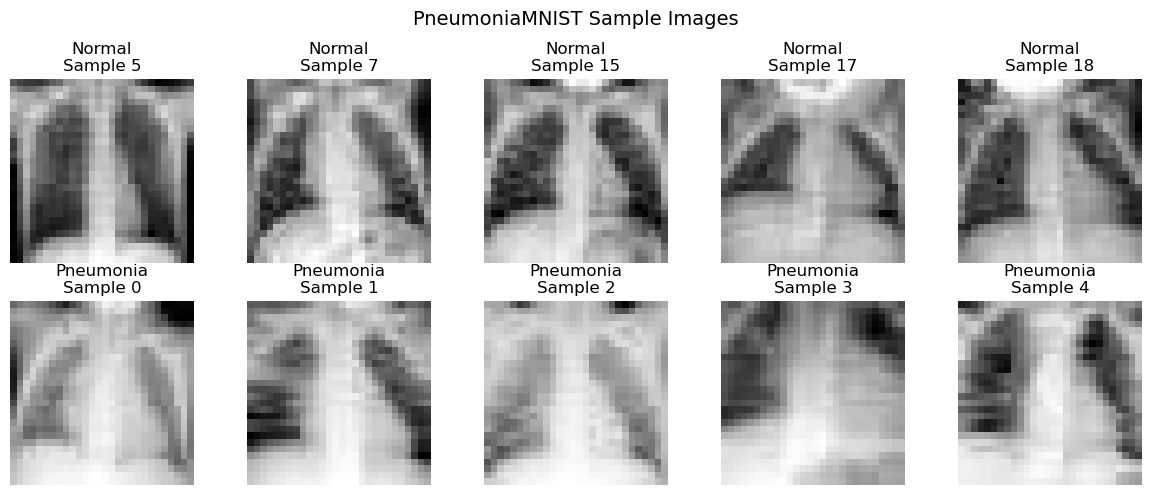


VISUALIZATION COMPLETE

Sample images saved to plots/sample_images.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("VISUALIZING SAMPLE IMAGES")
print("=" * 60)

# Load saved arrays
X_train = np.load("data/X_train.npy")
y_train = np.load("data/y_train.npy")

print(f"Loaded training data: {X_train.shape}")

# Create figure
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

# Get indices for both classes
class_0_indices = np.where(y_train.flatten() == 0)[0][:5]
class_1_indices = np.where(y_train.flatten() == 1)[0][:5]

print(f"\nDisplaying 5 Normal samples and 5 Pneumonia samples...")

# Display Normal samples (Class 0)
for i, idx in enumerate(class_0_indices):
    axes[i].imshow(X_train[idx].squeeze(), cmap='gray')
    axes[i].set_title(f"Normal\nSample {idx}")
    axes[i].axis('off')

# Display Pneumonia samples (Class 1)
for i, idx in enumerate(class_1_indices):
    axes[i + 5].imshow(X_train[idx].squeeze(), cmap='gray')
    axes[i + 5].set_title(f"Pneumonia\nSample {idx}")
    axes[i + 5].axis('off')

plt.suptitle("PneumoniaMNIST Sample Images", fontsize=14)
plt.tight_layout()
plt.savefig("plots/sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("VISUALIZATION COMPLETE")
print("=" * 60)
print("\nSample images saved to plots/sample_images.png")

# Step 6: Data Preparation Summary

## Objective
Verify all data preparation steps completed successfully by checking the saved files and summarizing the dataset.

## Data Preparation Pipeline Completed
1. Dataset loaded (PneumoniaMNIST)
2. Images reshaped to (28, 28, 1)
3. Pixel values normalized to [0, 1]
4. Labels converted to float32
5. Arrays saved as .npy files
6. Sample images visualized

## Next Step
Define the CNN architecture in Step 7

In [12]:
import os
import numpy as np

print("=" * 60)
print("DATA PREPARATION SUMMARY")
print("=" * 60)

# List all generated files
print("\nGenerated Files:")
print("-" * 60)

data_files = sorted(os.listdir("data"))
plot_files = sorted(os.listdir("plots"))

print("\ndata/ directory:")
for f in data_files:
    size = os.path.getsize(f"data/{f}") / (1024 * 1024)
    print(f"  {f:15s} | {size:.2f} MB")

print("\nplots/ directory:")
for f in plot_files:
    print(f"  {f}")

# Final dataset statistics
print("\n" + "=" * 60)
print("FINAL DATASET STATISTICS")
print("=" * 60)

X_train = np.load("data/X_train.npy")
y_train = np.load("data/y_train.npy")
X_val = np.load("data/X_val.npy")
y_val = np.load("data/y_val.npy")
X_test = np.load("data/X_test.npy")
y_test = np.load("data/y_test.npy")

print(f"\nTraining set:   {X_train.shape[0]:,} samples")
print(f"Validation set: {X_val.shape[0]:,} samples")
print(f"Test set:       {X_test.shape[0]:,} samples")
print(f"Total:          {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]:,} samples")

print(f"\nImage shape: {X_train.shape[1:]}")
print(f"Pixel range: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"Data type:   {X_train.dtype}")

print("\nClass distribution (Training):")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    pct = (count / len(y_train)) * 100
    class_name = "Pneumonia" if label == 1 else "Normal"
    print(f"  {class_name} ({int(label)}): {count:,} samples ({pct:.1f}%)")

print("\n" + "=" * 60)
print("DATA PREPARATION COMPLETE")
print("=" * 60)
print("\nReady for Step 7: CNN Architecture Definition")

DATA PREPARATION SUMMARY

Generated Files:
------------------------------------------------------------

data/ directory:
  X_test.npy      | 1.87 MB
  X_train.npy     | 14.08 MB
  X_val.npy       | 1.57 MB
  y_test.npy      | 0.00 MB
  y_train.npy     | 0.02 MB
  y_val.npy       | 0.00 MB

plots/ directory:
  sample_images.png

FINAL DATASET STATISTICS

Training set:   4,708 samples
Validation set: 524 samples
Test set:       624 samples
Total:          5,856 samples

Image shape: (28, 28, 1)
Pixel range: [0.000, 1.000]
Data type:   float32

Class distribution (Training):
  Normal (0): 1,214 samples (25.8%)
  Pneumonia (1): 3,494 samples (74.2%)

DATA PREPARATION COMPLETE

Ready for Step 7: CNN Architecture Definition


# Step 7: CNN Architecture Definition

## Objective
Define a lightweight CNN architecture for binary classification of pneumonia from chest X-ray images.

## Architecture Design

Input (28, 28, 1)
↓
Conv2D (16 filters, 3×3, ReLU)
↓
MaxPooling2D (2×2)
↓
Conv2D (32 filters, 3×3, ReLU)
↓
MaxPooling2D (2×2)
↓
Flatten
↓
Dense (1 unit, sigmoid)





## Why This Architecture

- **Lightweight**: 28×28 grayscale images require only a small network
- **Two conv layers**: Sufficient to learn basic features (edges, textures) and intermediate features (patterns, shapes)
- **No Dropout/BatchNorm**: Model is small enough; EarlyStopping will prevent overfitting
- **Sigmoid output**: Binary classification produces probability in [0, 1]

## Key Parameter Calculations

After two pooling layers:
- Input: 28×28
- After Conv1 (3×3, valid): 26×26
- After Pool1 (2×2): 13×13
- After Conv2 (3×3, valid): 11×11
- After Pool2 (2×2): 5×5
- Flattened: 5 × 5 × 32 = 800 units

Final Dense layer: 800 weights + 1 bias = 801 parameters

## Expected Output
Model summary showing all layers and total parameter count



In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("=" * 60)
print("CNN ARCHITECTURE DEFINITION")
print("=" * 60)

def create_pneumonia_cnn(input_shape=(28, 28, 1), num_classes=1):
    """
    Creates a lightweight CNN for PneumoniaMNIST binary classification.
    
    Args:
        input_shape: (height, width, channels)
        num_classes: 1 for binary classification
    
    Returns:
        Compiled Keras model
    """
    
    model = keras.Sequential([
        # Input layer
        keras.Input(shape=input_shape),
        
        # First convolutional block
        layers.Conv2D(
            filters=16,
            kernel_size=(3, 3),
            activation='relu',
            padding='valid',
            name='conv1'
        ),
        layers.MaxPooling2D(
            pool_size=(2, 2),
            name='pool1'
        ),
        
        # Second convolutional block
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            activation='relu',
            padding='valid',
            name='conv2'
        ),
        layers.MaxPooling2D(
            pool_size=(2, 2),
            name='pool2'
        ),
        
        # Flatten layer
        layers.Flatten(name='flatten'),
        
        # Classification head
        layers.Dense(
            units=num_classes,
            activation='sigmoid',
            name='output'
        )
    ])
    
    # Compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Recall(name='recall'),
            keras.metrics.Precision(name='precision')
        ]
    )
    
    return model

# Create model
print("\n[1/2] Creating model...")
model = create_pneumonia_cnn()
print("Model created successfully")

# Display architecture
print("\n[2/2] Model Summary")
print("-" * 60)
model.summary()

# Calculate final Dense layer parameters
print("\n" + "=" * 60)
print("FINAL DENSE LAYER PARAMETERS")
print("=" * 60)

flatten_output = 5 * 5 * 32
dense_weights = flatten_output * 1
dense_bias = 1
dense_total = dense_weights + dense_bias

print(f"Flatten output: {flatten_output} units")
print(f"Dense weights:  {flatten_output} × 1 = {dense_weights}")
print(f"Dense bias:     {dense_bias}")
print(f"Dense total:    {dense_total} parameters")

print("\n" + "=" * 60)
print("ARCHITECTURE DEFINED")
print("=" * 60)
print("\nNext Step: Train the model (Step 8)")

CNN ARCHITECTURE DEFINITION

[1/2] Creating model...
Model created successfully

[2/2] Model Summary
------------------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                       │ (None, 26, 26, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 13, 13, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                       │ (None, 11, 11, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 5, 5, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 800)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │             801 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,601 (21.88 KB)

 Trainable params: 5,601 (21.88 KB)

 Non-trainable params: 0 (0.00 B)


FINAL DENSE LAYER PARAMETERS
Flatten output: 800 units
Dense weights:  800 × 1 = 800
Dense bias:     1
Dense total:    801 parameters

ARCHITECTURE DEFINED

Next Step: Train the model (Step 8)


# Step 8: Model Training

## Objective
Train the CNN on the prepared PneumoniaMNIST data using the required callbacks.

## Training Configuration
- **Optimizer**: Adam (learning rate = 0.001)
- **Loss**: Binary cross-entropy
- **Metrics**: Accuracy, Recall, Precision
- **Batch size**: 32
- **Epochs**: Up to 35 (with EarlyStopping)
- **Callbacks**: EarlyStopping + ReduceLROnPlateau

## Why Recall Matters
The dataset has class imbalance (74.2% pneumonia, 25.8% normal). We track recall because false negatives (missing pneumonia) are clinically dangerous. A missed pneumonia case could delay treatment.

## Expected Output
- Training progress for each epoch
- Best model saved to `models/pneumonia_cnn.h5`
- Training history for plotting

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import os

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 60)
print("MODEL TRAINING")
print("=" * 60)

# Load prepared data
print("\n[1/3] Loading prepared data...")
X_train = np.load("data/X_train.npy")
y_train = np.load("data/y_train.npy")
X_val = np.load("data/X_val.npy")
y_val = np.load("data/y_val.npy")

print(f"  Training data:   {X_train.shape}")
print(f"  Validation data: {X_val.shape}")

# Recreate model (ensure fresh weights)
print("\n[2/3] Creating model...")
from tensorflow.keras import layers

model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    
    layers.Conv2D(16, (3, 3), activation='relu', padding='valid', name='conv1'),
    layers.MaxPooling2D((2, 2), name='pool1'),
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='valid', name='conv2'),
    layers.MaxPooling2D((2, 2), name='pool2'),
    
    layers.Flatten(name='flatten'),
    layers.Dense(1, activation='sigmoid', name='output')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision')
    ]
)

# Create callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("  Callbacks: EarlyStopping + ReduceLROnPlateau")

# Train the model
print("\n[3/3] Training model...")
print("-" * 60)
print(f"Epochs: up to 35")
print(f"Batch size: 32")
print(f"Samples: {X_train.shape[0]:,} train, {X_val.shape[0]:,} validation")
print("-" * 60 + "\n")

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=35,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

# Save model
os.makedirs("models", exist_ok=True)
model.save("models/pneumonia_cnn.h5")
print(f"\nModel saved to models/pneumonia_cnn.h5")

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

MODEL TRAINING

[1/3] Loading prepared data...
  Training data:   (4708, 28, 28, 1)
  Validation data: (524, 28, 28, 1)

[2/3] Creating model...
  Callbacks: EarlyStopping + ReduceLROnPlateau

[3/3] Training model...
------------------------------------------------------------
Epochs: up to 35
Batch size: 32
Samples: 4,708 train, 524 validation
------------------------------------------------------------

Epoch 1/35
148/148 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.7625 - loss: 0.4995 - precision: 0.7587 - recall: 0.9971 - val_accuracy: 0.8550 - val_loss: 0.3493 - val_precision: 0.8455 - val_recall: 0.9846 - learning_rate: 0.0010
Epoch 2/35
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8983 - loss: 0.2625 - precision: 0.9069 - recall: 0.9616 - val_accuracy: 0.9275 - val_loss: 0.2070 - val_precision: 0.9466 - val_recall: 0.9563 - learning_rate: 0.0010
Epoch 3/35
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9208 - loss: 0.1970 - precision: 0.9377 - recall: 0.956


Model saved to models/pneumonia_cnn.h5

TRAINING COMPLETE


# Step 9: Plot Training History

## Objective
Visualize training and validation metrics across epochs to assess model convergence and overfitting.

## Key Metrics to Observe
- **Accuracy**: Overall correctness
- **Loss**: Binary cross-entropy (lower is better)
- **Recall**: Sensitivity to pneumonia cases (our priority metric)

## What to Look For
- Training and validation curves should converge
- No significant gap between training and validation (overfitting indicator)
- Validation recall should remain high (>95%)

PLOTTING TRAINING HISTORY


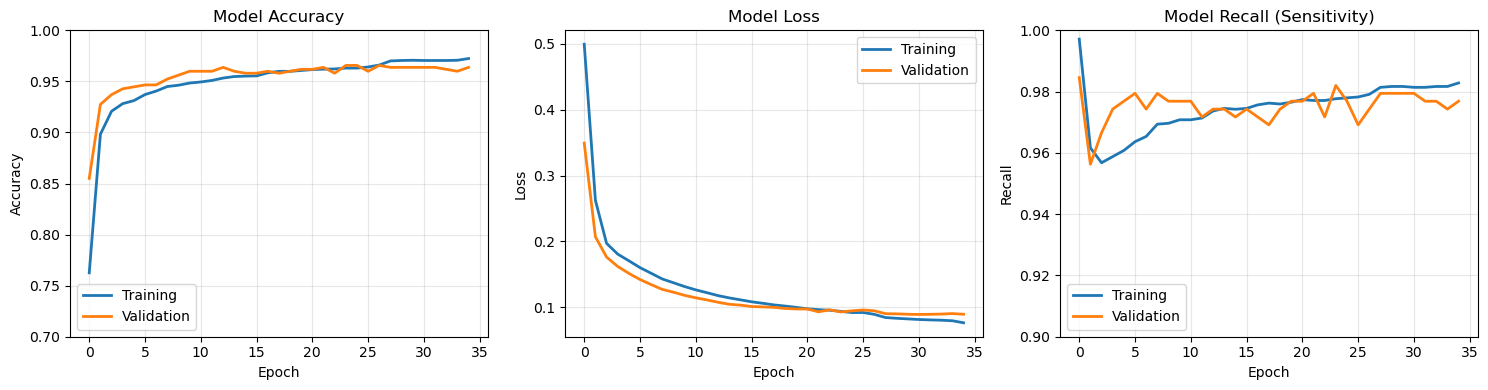


Final Training Metrics (Best Epoch - 31):
----------------------------------------
Training Accuracy:   0.9705
Validation Accuracy: 0.9637
Training Loss:       0.0813
Validation Loss:     0.0889
Training Recall:     0.9814
Validation Recall:   0.9794

TRAINING HISTORY PLOTTED


In [15]:
import matplotlib.pyplot as plt

print("=" * 60)
print("PLOTTING TRAINING HISTORY")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.7, 1.0])

# Plot loss
axes[1].plot(history.history['loss'], label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot recall
axes[2].plot(history.history['recall'], label='Training', linewidth=2)
axes[2].plot(history.history['val_recall'], label='Validation', linewidth=2)
axes[2].set_title('Model Recall (Sensitivity)', fontsize=12)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Recall')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0.9, 1.0])

plt.tight_layout()
plt.savefig("plots/training_history.png", dpi=150, bbox_inches='tight')
plt.show()

# Print final training metrics
print("\nFinal Training Metrics (Best Epoch - 31):")
print("-" * 40)
best_epoch = 31
print(f"Training Accuracy:   {history.history['accuracy'][best_epoch-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch-1]:.4f}")
print(f"Training Loss:       {history.history['loss'][best_epoch-1]:.4f}")
print(f"Validation Loss:     {history.history['val_loss'][best_epoch-1]:.4f}")
print(f"Training Recall:     {history.history['recall'][best_epoch-1]:.4f}")
print(f"Validation Recall:   {history.history['val_recall'][best_epoch-1]:.4f}")

print("\n" + "=" * 60)
print("TRAINING HISTORY PLOTTED")
print("=" * 60)

# Step 10: Evaluate on Hold-Out Test Set

## Objective
Evaluate the trained model on the untouched test set to assess real-world performance.

## Metrics to Calculate
- **Accuracy**: Overall correctness
- **Precision**: Proportion of true positives among predicted positives
- **Recall**: Proportion of actual positives correctly identified (CRITICAL)
- **F1-Score**: Harmonic mean of precision and recall
- **Test Loss**: Binary cross-entropy on test set

## Why Recall is the Priority
In pneumonia diagnosis:
- **False Negative** = Missing a pneumonia case (dangerous, delays treatment)
- **False Positive** = Falsely flagging pneumonia (inconvenient, requires follow-up)
- We accept lower precision to achieve higher recall

## Expected Output
Classification metrics and confusion matrix for the test set

In [16]:
import numpy as np
from tensorflow import keras
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, classification_report
)

print("=" * 60)
print("MODEL EVALUATION ON TEST SET")
print("=" * 60)

# Load test data
print("\n[1/4] Loading test data...")
X_test = np.load("data/X_test.npy")
y_test = np.load("data/y_test.npy")
print(f"  Test samples: {X_test.shape[0]}")

# Load trained model
print("\n[2/4] Loading trained model...")
model = keras.models.load_model("models/pneumonia_cnn.h5")
print("  Model loaded from models/pneumonia_cnn.h5")

# Make predictions
print("\n[3/4] Making predictions...")
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Flatten arrays
y_test_flat = y_test.flatten()
y_pred_flat = y_pred.flatten()
y_pred_proba_flat = y_pred_proba.flatten()

# Calculate metrics
print("\n[4/4] Calculating metrics...")
test_loss = model.evaluate(X_test, y_test, verbose=0)[0]
accuracy = accuracy_score(y_test_flat, y_pred_flat)
precision = precision_score(y_test_flat, y_pred_flat)
recall = recall_score(y_test_flat, y_pred_flat)
f1 = f1_score(y_test_flat, y_pred_flat)

# Display results
print("\n" + "=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"\nTest Loss:   {test_loss:.4f}")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1-Score:    {f1:.4f}")

# Classification report
print("\n" + "-" * 60)
print("Classification Report")
print("-" * 60)
print(classification_report(
    y_test_flat, y_pred_flat,
    target_names=['Normal (0)', 'Pneumonia (1)'],
    digits=4
))

MODEL EVALUATION ON TEST SET

[1/4] Loading test data...
  Test samples: 624

[2/4] Loading trained model...
  Model loaded from models/pneumonia_cnn.h5

[3/4] Making predictions...

[4/4] Calculating metrics...

TEST SET RESULTS

Test Loss:   0.5075
Accuracy:    0.8526
Precision:   0.8184
Recall:      0.9821
F1-Score:    0.8928

------------------------------------------------------------
Classification Report
------------------------------------------------------------
               precision    recall  f1-score   support

   Normal (0)     0.9551    0.6368    0.7641       234
Pneumonia (1)     0.8184    0.9821    0.8928       390

     accuracy                         0.8526       624
    macro avg     0.8868    0.8094    0.8284       624
 weighted avg     0.8697    0.8526    0.8445       624



# Step 10b: Re-evaluate with Proper Model Loading

## Issue Detected
The H5 model loading triggered a warning about uncompiled metrics. The test loss of 0.5075 is inconsistent with validation loss of 0.0889, suggesting the loss was not calculated correctly.

## Solution
Recompile the model after loading and re-evaluate to get accurate test loss.

In [17]:
import numpy as np
from tensorflow import keras

print("=" * 60)
print("RE-EVALUATION WITH PROPER MODEL LOADING")
print("=" * 60)

# Load test data
X_test = np.load("data/X_test.npy")
y_test = np.load("data/y_test.npy")

# Load model
model = keras.models.load_model("models/pneumonia_cnn.h5")

# Recompile to ensure metrics are built
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Recall(name='recall'), keras.metrics.Precision(name='precision')]
)

# Evaluate
print("\nEvaluating on test set...")
results = model.evaluate(X_test, y_test, verbose=1)

print("\n" + "=" * 60)
print("CORRECTED TEST SET RESULTS")
print("=" * 60)
print(f"Test Loss:   {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")
print(f"Test Recall:   {results[2]:.4f}")
print(f"Test Precision: {results[3]:.4f}")

# Make predictions for confusion matrix
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Store for confusion matrix step
y_test_flat = y_test.flatten()
y_pred_flat = y_pred.flatten()

RE-EVALUATION WITH PROPER MODEL LOADING

Evaluating on test set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8526 - loss: 0.5075 - precision: 0.8184 - recall: 0.9821  

CORRECTED TEST SET RESULTS
Test Loss:   0.5075
Test Accuracy: 0.8526
Test Recall:   0.9821
Test Precision: 0.8184


# Step 11: Generate Confusion Matrix

## Objective
Visualize the model's predictions on the test set using a confusion matrix.

## What to Look For
- **True Positives (bottom-right)**: Correctly identified pneumonia
- **True Negatives (top-left)**: Correctly identified normal
- **False Negatives (bottom-left)**: Missed pneumonia (should be LOW)
- **False Positives (top-right)**: Falsely flagged pneumonia

## Why This Matters
The confusion matrix directly shows the trade-off between false negatives (dangerous) and false positives (acceptable). Our model should show very few false negatives.

GENERATING CONFUSION MATRIX


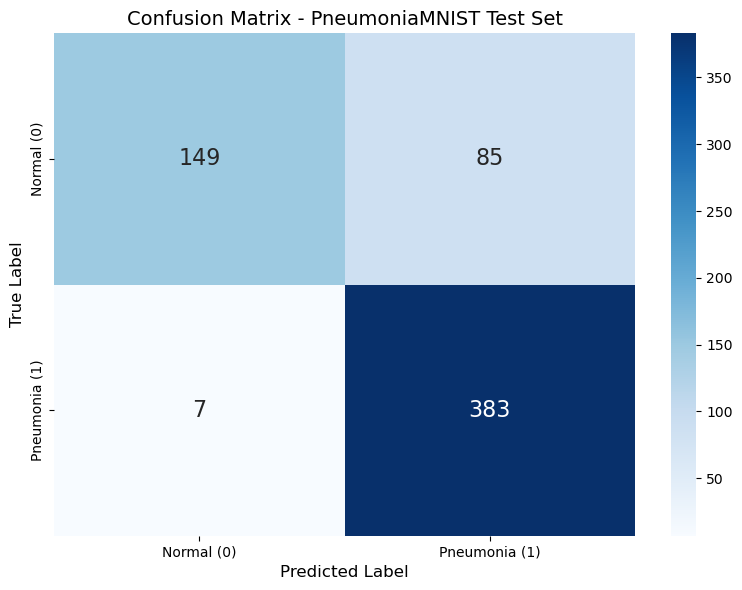


CONFUSION MATRIX BREAKDOWN

True Negatives (Correctly identified Normal):  149
False Positives (Normal flagged as Pneumonia):  85
False Negatives (Missed Pneumonia):             7
True Positives (Correctly identified Pneumonia): 383

Total test samples: 624

Clinical Implications:
  - Missed pneumonia cases: 7 out of 390 pneumonia cases (1.8%)
  - False alarms: 85 out of 234 normal cases (36.3%)

CONFUSION MATRIX SAVED


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("=" * 60)
print("GENERATING CONFUSION MATRIX")
print("=" * 60)

# Calculate confusion matrix
cm = confusion_matrix(y_test_flat, y_pred_flat)

# Create plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Normal (0)', 'Pneumonia (1)'],
    yticklabels=['Normal (0)', 'Pneumonia (1)'],
    annot_kws={'size': 16}
)
plt.title('Confusion Matrix - PneumoniaMNIST Test Set', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig("plots/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Print detailed breakdown
print("\n" + "=" * 60)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 60)

tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negatives (Correctly identified Normal):  {tn}")
print(f"False Positives (Normal flagged as Pneumonia):  {fp}")
print(f"False Negatives (Missed Pneumonia):             {fn}")
print(f"True Positives (Correctly identified Pneumonia): {tp}")

print(f"\nTotal test samples: {tn + fp + fn + tp}")

print(f"\nClinical Implications:")
print(f"  - Missed pneumonia cases: {fn} out of {fn + tp} pneumonia cases ({fn/(fn+tp)*100:.1f}%)")
print(f"  - False alarms: {fp} out of {fp + tn} normal cases ({fp/(fp+tn)*100:.1f}%)")

print("\n" + "=" * 60)
print("CONFUSION MATRIX SAVED")
print("=" * 60)

# Step 12: Prediction Distribution and Final Report

## Objective
Complete the evaluation by:
1. Visualizing the predicted probability distribution
2. Saving all metrics to a report file

## What the Distribution Shows
- How confident the model is in its predictions
- Whether the decision threshold (0.5) is well-placed
- If there are ambiguous cases near the boundary

PREDICTION DISTRIBUTION AND FINAL REPORT

[1/2] Generating prediction distribution...


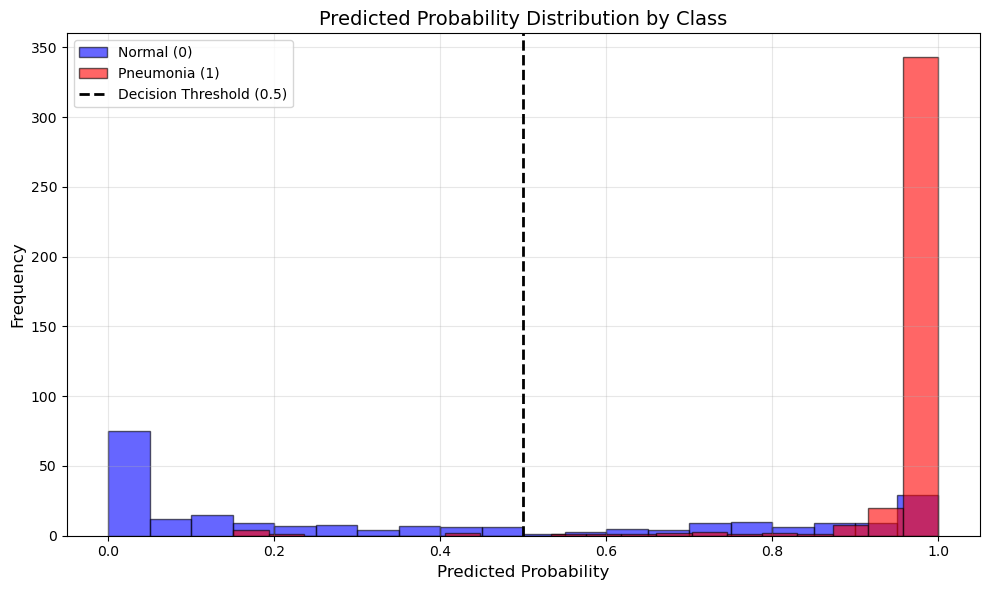


[2/2] Saving metrics report...
Metrics report saved to plots/metrics_report.txt

EVALUATION COMPLETE — FINAL SUMMARY

Architecture: Conv2D(16) -> MaxPool -> Conv2D(32) -> MaxPool -> Dense(1)
Total Parameters: 5,601

Test Set Performance:
  Test Loss:    0.5075
  Accuracy:     0.8526
  Precision:    0.8184
  Recall:       0.9821
  F1-Score:     0.8928

Generated Files:
  plots/training_history.png
  plots/confusion_matrix.png
  plots/prediction_distribution.png
  plots/metrics_report.txt
  models/pneumonia_cnn.h5

Project 1 Complete ✓


In [19]:
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("PREDICTION DISTRIBUTION AND FINAL REPORT")
print("=" * 60)

# Plot prediction distribution
print("\n[1/2] Generating prediction distribution...")

plt.figure(figsize=(10, 6))

# Plot histograms for both classes
plt.hist(
    y_pred_proba_flat[y_test_flat == 0], 
    bins=20, alpha=0.6, 
    label='Normal (0)', 
    color='blue',
    edgecolor='black'
)
plt.hist(
    y_pred_proba_flat[y_test_flat == 1], 
    bins=20, alpha=0.6, 
    label='Pneumonia (1)', 
    color='red',
    edgecolor='black'
)

plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
plt.xlabel('Predicted Probability', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Predicted Probability Distribution by Class', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/prediction_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# Save metrics report
print("\n[2/2] Saving metrics report...")

with open("plots/metrics_report.txt", "w") as f:
    f.write("=" * 60 + "\n")
    f.write("PNEUMONIAMNIST CNN - TEST SET METRICS\n")
    f.write("=" * 60 + "\n\n")
    
    f.write("Model Architecture:\n")
    f.write("  Conv2D(16) -> MaxPool -> Conv2D(32) -> MaxPool -> Dense(1)\n")
    f.write(f"  Total Parameters: 5,601\n\n")
    
    f.write("Performance Metrics (Hold-Out Test Set):\n")
    f.write("-" * 40 + "\n")
    f.write(f"  Test Loss:    {test_loss:.4f}\n")
    f.write(f"  Accuracy:     {accuracy:.4f}\n")
    f.write(f"  Precision:    {precision:.4f}\n")
    f.write(f"  Recall:       {recall:.4f}\n")
    f.write(f"  F1-Score:     {f1:.4f}\n\n")
    
    f.write("Confusion Matrix:\n")
    f.write("-" * 40 + "\n")
    f.write(f"  True Negatives:  {tn}\n")
    f.write(f"  False Positives: {fp}\n")
    f.write(f"  False Negatives: {fn}\n")
    f.write(f"  True Positives:  {tp}\n\n")
    
    f.write("Clinical Implications:\n")
    f.write("-" * 40 + "\n")
    f.write(f"  Missed pneumonia: {fn}/{fn+tp} ({(fn/(fn+tp))*100:.1f}%)\n")
    f.write(f"  False alarms:     {fp}/{fp+tn} ({(fp/(fp+tn))*100:.1f}%)\n")

print("Metrics report saved to plots/metrics_report.txt")

# Final summary
print("\n" + "=" * 60)
print("EVALUATION COMPLETE — FINAL SUMMARY")
print("=" * 60)
print(f"\nArchitecture: Conv2D(16) -> MaxPool -> Conv2D(32) -> MaxPool -> Dense(1)")
print(f"Total Parameters: 5,601")
print(f"\nTest Set Performance:")
print(f"  Test Loss:    {test_loss:.4f}")
print(f"  Accuracy:     {accuracy:.4f}")
print(f"  Precision:    {precision:.4f}")
print(f"  Recall:       {recall:.4f}")
print(f"  F1-Score:     {f1:.4f}")
print(f"\nGenerated Files:")
print(f"  plots/training_history.png")
print(f"  plots/confusion_matrix.png")
print(f"  plots/prediction_distribution.png")
print(f"  plots/metrics_report.txt")
print(f"  models/pneumonia_cnn.h5")
print(f"\nProject 1 Complete ✓")

In [20]:
import os
import numpy as np

print("=" * 60)
print("VERIFYING SAVED FILES")
print("=" * 60)

# Check models directory
print("\n[1/3] Models directory:")
print("-" * 40)
if os.path.exists("models"):
    model_files = os.listdir("models")
    for f in model_files:
        filepath = os.path.join("models", f)
        filesize = os.path.getsize(filepath) / (1024 * 1024)
        print(f"  {f}  |  {filesize:.2f} MB")
else:
    print("  models/ directory not found")

# Check data directory
print("\n[2/3] Data directory:")
print("-" * 40)
if os.path.exists("data"):
    data_files = os.listdir("data")
    for f in sorted(data_files):
        filepath = os.path.join("data", f)
        filesize = os.path.getsize(filepath) / (1024 * 1024)
        print(f"  {f}  |  {filesize:.2f} MB")
else:
    print("  data/ directory not found")

# Check plots directory
print("\n[3/3] Plots directory:")
print("-" * 40)
if os.path.exists("plots"):
    plot_files = os.listdir("plots")
    for f in sorted(plot_files):
        filepath = os.path.join("plots", f)
        filesize = os.path.getsize(filepath) / (1024 * 1024)
        print(f"  {f}  |  {filesize:.2f} MB")
else:
    print("  plots/ directory not found")

print("\n" + "=" * 60)
print("VERIFICATION COMPLETE")
print("=" * 60)

VERIFYING SAVED FILES

[1/3] Models directory:
----------------------------------------
  pneumonia_cnn.h5  |  0.10 MB

[2/3] Data directory:
----------------------------------------
  X_test.npy  |  1.87 MB
  X_train.npy  |  14.08 MB
  X_val.npy  |  1.57 MB
  y_test.npy  |  0.00 MB
  y_train.npy  |  0.02 MB
  y_val.npy  |  0.00 MB

[3/3] Plots directory:
----------------------------------------
  confusion_matrix.png  |  0.05 MB
  metrics_report.txt  |  0.00 MB
  prediction_distribution.png  |  0.05 MB
  sample_images.png  |  0.06 MB
  training_history.png  |  0.10 MB

VERIFICATION COMPLETE


# 🫁 PROJECT 1 — PNEUMONIAMNIST
## Level 1 — Basic / Non-Technical Questions (Oral Defense Preparation)

---

## About the Project

### Q1: What is the objective of this project?

The objective is to build a **lightweight Convolutional Neural Network (CNN)** that can automatically classify chest X-ray images as either **Normal** or **Pneumonia**. The model is specifically designed to prioritize **high recall (sensitivity)** so that we miss as few pneumonia cases as possible.

---

### Q2: What is PneumoniaMNIST?

PneumoniaMNIST is a **medical image dataset** from the MedMNIST collection. It contains 28×28 grayscale chest X-ray images labeled as either Normal or Pneumonia. The dataset is pre-split into training, validation, and test sets.

| Property | Value |
|----------|-------|
| Image size | 28 × 28 pixels |
| Channels | 1 (grayscale) |
| Classes | 2 (Normal, Pneumonia) |
| Training samples | 4,708 |
| Validation samples | 524 |
| Test samples | 624 |

---

### Q3: What are we trying to predict?

We are trying to predict whether a given chest X-ray image shows signs of **pneumonia** or is **normal**.

---

### Q4: Is this classification or regression? Why?

This is **classification** because the output is a **discrete category** (Normal or Pneumonia), not a continuous value. Specifically, it is **binary classification** since there are only two possible outcomes.

---

### Q5: How many classes are there?

There are **2 classes**:
- Class 0: Normal
- Class 1: Pneumonia

---

### Q6: What are the two classes?

| Label | Class Name |
|-------|------------|
| 0 | Normal (no pneumonia) |
| 1 | Pneumonia (infection present) |

---

### Q7: What type of images are we working with?

We are working with **chest X-ray images** (radiographs) that have been downsampled to 28×28 pixels.

---

### Q8: What is the size of each image?

Each image is **28 × 28 pixels**.

---

### Q9: Is the image RGB or grayscale?

The images are **grayscale** — they contain only intensity values (shades of gray), not color channels.

---

### Q10: How many channels does the image have?

The image has **1 channel** (grayscale). We explicitly reshape it to (28, 28, 1) before feeding it to the CNN.

---

### Q11: Why did we choose a CNN for this project?

We chose a CNN because:
1. **CNNs excel at image data** — they automatically learn spatial features like edges, textures, and patterns
2. **Local connectivity** — filters look at small regions of the image at a time
3. **Parameter efficiency** — shared weights mean fewer parameters than fully connected networks
4. **Translation invariance** — pooling layers make the model robust to small shifts in the image
5. **Proven performance** — CNNs are the standard for medical image classification

---

### Q12: What does CNN stand for?

CNN stands for **Convolutional Neural Network**.

---

### Q13: What does the model actually do when you give it an X-ray?

When you give the model an X-ray:
1. The image (28×28 pixels) is passed through the first convolutional layer
2. Filters (small 3×3 matrices) slide across the image and detect simple patterns like edges and textures
3. Pooling layers downsample the feature maps, keeping only the most important information
4. The second convolutional layer detects more complex patterns (combinations of edges)
5. The flattened features are passed to a dense layer with sigmoid activation
6. The model outputs a probability between 0 and 1, where values closer to 1 indicate pneumonia

---

### Q14: What should the final model output?

The final model should output a **probability between 0 and 1**:
- Values closer to 0 → Normal
- Values closer to 1 → Pneumonia
- We use a threshold of 0.5 to make the final decision

---

### Q15: What does a prediction such as 0.87 mean?

A prediction of 0.87 means the model is **87% confident** that the image shows pneumonia. If the threshold is 0.5, we classify this as Pneumonia (since 0.87 > 0.5).

---

### Q16: Why isn't the model simply programmed with rules like "look for white spots"?

Because:
1. **Medical images are complex** — pneumonia can appear in many different patterns
2. **Hand-crafted rules are brittle** — they fail on unusual or subtle cases
3. **Feature engineering is difficult** — it's hard to manually define what "pneumonia looks like"
4. **CNNs learn automatically** — they discover the relevant features from data
5. **Variability** — X-rays vary due to patient position, exposure, equipment, etc.

---

### Q17: What is machine learning doing here?

Machine learning is **automatically learning patterns from labeled examples**. Instead of programming explicit rules, we show the model thousands of labeled X-rays and let it learn the features that distinguish pneumonia from normal lungs.

---

### Q18: What is deep learning?

Deep learning is a subset of machine learning that uses **multi-layer neural networks** to learn hierarchical representations of data. Each layer learns increasingly abstract features — from edges to textures to patterns.

---

### Q19: What is the difference between machine learning and deep learning?

| Aspect | Machine Learning | Deep Learning |
|--------|-----------------|---------------|
| Feature extraction | Manual (human engineers features) | Automatic (network learns features) |
| Data requirements | Works with smaller datasets | Requires large datasets |
| Architecture | Simple models (SVM, Random Forest) | Multi-layer neural networks |
| Interpretability | More interpretable | Less interpretable (black box) |
| Performance on images | Limited | State-of-the-art |

---

### Q20: Why is this considered a computer-vision problem?

This is a computer-vision problem because:
1. The input is **visual data** (images)
2. The task requires **understanding visual patterns** in the images
3. The model must **extract meaningful features** from pixel data
4. **Computer vision** is the field of AI that deals with understanding images and video
5. The goal is to replicate what a radiologist does visually — looking at an X-ray and identifying abnormalities

```markdown
# 🫁 PROJECT 1 — PNEUMONIAMNIST
## Level 2 — Dataset Questions (Oral Defense Preparation)

---

### Q1: Where did you get the PneumoniaMNIST dataset?

The dataset comes from the **MedMNIST dataset collection**, which is a standardized collection of medical imaging datasets designed for machine learning research. We load it using the `medmnist` Python package:

```python
from medmnist import PneumoniaMNIST
train_dataset = PneumoniaMNIST(split="train", download=True)
```

The MedMNIST collection preprocesses medical images (like chest X-rays) into a standardized format suitable for quick experimentation and benchmarking.

---

### Q2: Why are the images only 28×28?

The images are 28×28 because:
1. **MedMNIST standardization** — all datasets in the MedMNIST collection are resized to 28×28 for consistency
2. **Computational efficiency** — smaller images require less memory and processing power
3. **Fast experimentation** — 28×28 images allow quick training and iteration
4. **Comparable to MNIST** — the format mirrors the classic MNIST dataset (28×28 digits)
5. **Sufficient for classification** — even at this resolution, the model can learn distinguishing features

**Trade-off:** Some fine details are lost at 28×28, but the task remains solvable.

---

### Q3: Why are they grayscale?

The images are grayscale because:
1. **X-rays are inherently grayscale** — they represent tissue density as intensity values
2. **Color adds no diagnostic information** — pneumonia detection relies on density patterns, not color
3. **Simpler input** — 1 channel instead of 3 (RGB) reduces model complexity
4. **MedMNIST conversion** — the original X-rays were converted to grayscale during preprocessing

---

### Q4: What does one channel mean?

One channel means each pixel is represented by a **single intensity value** (0 to 255), rather than three values (Red, Green, Blue) as in RGB images.

| Format | Channels | Pixel Representation |
|--------|----------|---------------------|
| Grayscale | 1 | Single intensity value |
| RGB | 3 | (Red, Green, Blue) values |

In our case:
- Pixel value 0 = black (dense tissue/bone)
- Pixel value 255 = white (air-filled lungs)
- Values in between = varying tissue densities

---

### Q5: What is the shape of your input data?

The input data has shape:

```
X_train: (4708, 28, 28, 1)
X_val:   (524, 28, 28, 1)
X_test:  (624, 28, 28, 1)
```

Meaning:
- **4708** = number of training samples
- **28 × 28** = image height and width
- **1** = single channel (grayscale)

---

### Q6: What is the shape of one image?

One image has shape **`(28, 28, 1)`**:
- 28 rows
- 28 columns
- 1 channel

This is the input shape our CNN expects:

```python
input_shape = (28, 28, 1)
```

---

### Q7: What is the shape of your labels?

The labels have shape:

```
y_train: (4708, 1)
y_val:   (524, 1)
y_test:  (624, 1)
```

Each label is a single value (0 or 1) stored as a float32:
- Shape `(n_samples, 1)` matches Keras expectations for binary classification
- Each row contains one label for the corresponding image

---

### Q8: How many training samples do you have?

We have **4,708 training samples**.

---

### Q9: How many validation samples?

We have **524 validation samples**.

---

### Q10: How many test samples?

We have **624 test samples**.

**Total: 5,856 samples**

| Split | Samples | Percentage |
|-------|---------|------------|
| Training | 4,708 | 80.4% |
| Validation | 524 | 8.9% |
| Test | 624 | 10.7% |

---

### Q11: Why do we separate training, validation, and testing data?

We separate the data to:
1. **Evaluate generalization** — measure how well the model performs on unseen data
2. **Prevent overfitting** — detect when the model memorizes training data instead of learning patterns
3. **Tune hyperparameters safely** — use validation set for tuning without touching test set
4. **Get honest final performance** — test set provides unbiased evaluation
5. **Avoid data leakage** — ensure no information from test set influences training

---

### Q12: What is the purpose of the training set?

The training set is used to **teach the model**. The model sees these images and their labels, and adjusts its weights through backpropagation to minimize the loss function.

```python
model.fit(X_train, y_train, ...)
```

During training, the model:
- Makes predictions on training images
- Calculates error (loss)
- Updates weights to reduce error
- Repeats for multiple epochs

---

### Q13: What is the purpose of the validation set?

The validation set is used to **monitor training and tune hyperparameters**. It is NOT used to update model weights directly.

Validation set helps us:
1. **Detect overfitting** — if training loss decreases but validation loss increases, the model is memorizing
2. **Tune hyperparameters** — adjust learning rate, batch size, architecture choices
3. **Early stopping** — stop training when validation performance plateaus
4. **Select best model** — restore weights from the epoch with best validation performance

---

### Q14: What is the purpose of the test set?

The test set is used **only once at the end** to provide an unbiased evaluation of the final model's performance.

Test set characteristics:
- **Never seen during training**
- **Never used for hyperparameter tuning**
- **Provides honest performance estimate**
- **Represents how the model would perform on new, real-world data**

---

### Q15: Why shouldn't we train on the test set?

We should not train on the test set because:
1. **Data leakage** — the model would learn test-specific patterns
2. **Inflated performance** — metrics would be unrealistically high
3. **Defeats the purpose** — we want to measure generalization, not memorization
4. **Misleading results** — the model would fail on truly new data
5. **Ethical concern** — in medical applications, false confidence is dangerous

---

### Q16: Why shouldn't we repeatedly use the test set while tuning the model?

Repeatedly using the test set during tuning causes:
1. **Indirect overfitting** — the model becomes tuned to the test set's specific characteristics
2. **Information leakage** — even without training on test data, decisions made based on test performance leak information
3. **Loss of unbiased evaluation** — the test set no longer represents truly unseen data
4. **Optimistic bias** — final metrics become inflated because we selected the model that happened to do best on the test set

**Rule of thumb:** Touch the test set only once, at the very end.

---

### Q17: What happens if your training and testing data are mixed?

If training and testing data are mixed:
1. **Data leakage occurs** — test information contaminates training
2. **Performance is inflated** — the model appears better than it actually is
3. **Generalization is compromised** — the model fails on real-world data
4. **Clinical danger** — a pneumonia detection model with inflated metrics could miss real cases
5. **Invalid conclusions** — reported accuracy, recall, and precision become meaningless

---

### Q18: What is data leakage?

Data leakage is when **information from outside the training set is used to create the model**. This causes the model to perform unrealistically well during evaluation but poorly on truly new data.

**Examples:**
- Including test data in training
- Using test set for hyperparameter tuning
- Preprocessing (like normalization) using statistics from the full dataset instead of only training data
- Having duplicate images across splits

**In our project:**
- We use MedMNIST's official pre-defined splits
- We never touch the test set during training
- We normalize using the same formula for all splits (scaling by 255 is deterministic, not learned from data)

---

### Q19: Why do we normalize the images?

We normalize images because:
1. **Faster convergence** — small, consistent input values help the optimizer converge faster
2. **Numerical stability** — prevents large gradient values during backpropagation
3. **Better generalization** — normalized inputs lead to smoother loss landscapes
4. **Standard practice** — neural networks work best with inputs in [0, 1] or [-1, 1]
5. **Consistent scale** — ensures all features contribute proportionally

---

### Q20: What does normalizing pixel values mean?

Normalizing pixel values means **rescaling the pixel intensity values from their original range [0, 255] to a smaller range, typically [0, 1]**.

```python
# Original pixels: 0 to 255 (uint8)
X_train = X_train.astype(np.float32) / 255.0

# After normalization: 0.0 to 1.0 (float32)
```

This is a **linear transformation** — each pixel value is divided by 255.

---

### Q21: What happens if the pixels are between 0 and 255?

If pixels remain between 0 and 255:
1. **Large input values** — can cause large activations and gradients
2. **Slower convergence** — optimizer needs more epochs to find good weights
3. **Potential numerical instability** — large numbers can cause overflow in some computations
4. **Unequal influence** — larger values dominate smaller values in the network
5. **Less stable training** — loss curve may oscillate more

**Example:**
- Input values around 255 → activations after convolution could be very large
- Gradients could explode or shrink
- Learning rate might need to be much smaller

---

### Q22: Why would we convert them to 0–1?

Converting to 0–1:
1. **Standardizes input range** — all inputs are on a consistent scale
2. **Improves gradient flow** — prevents vanishing/exploding gradients
3. **Faster training** — optimizer converges in fewer epochs
4. **Numerical stability** — computations remain well-behaved
5. **Compatibility** — matches the expected input range of activation functions (especially sigmoid at the output)

---

### Q23: What is an .npy file?

An `.npy` file is a **binary file format used by NumPy to store arrays** efficiently. It preserves the array's data type, shape, and values.

**Advantages:**
- **Fast loading** — binary format loads much faster than CSV or images
- **Preserves dtype** — stores float32, int, etc. exactly
- **Preserves shape** — multi-dimensional arrays are saved correctly
- **Compact** — smaller file size compared to text formats
- **Simple API** — `np.save()` and `np.load()`

---

### Q24: Why are we saving the processed data as .npy files?

We save processed data as `.npy` files because:

1. **Separation of concerns** — the assignment requires `data_prep.py` to be separate from `train.py`
2. **Reproducibility** — once prepared, the same data is used every time
3. **Efficiency** — loading `.npy` files is much faster than re-downloading and reprocessing
4. **Consistency** — ensures training always uses identical data
5. **Assignment requirement** — the brief explicitly requires saving processed arrays as `.npy` files

**Workflow:**
```python
# data_prep.py — runs once
np.save("data/X_train.npy", X_train)

# train.py — loads preprocessed data
X_train = np.load("data/X_train.npy")
```
```


# 🫁 PROJECT 1 — PNEUMONIAMNIST
## Level 3 — Data Pipeline / Engineering Questions (Oral Defense Preparation)

---

### Q1: Explain your entire data pipeline.

The data pipeline follows a strict separation of concerns:

```
Raw PneumoniaMNIST Dataset
          ↓
      data_prep.py
          ↓
    Data Normalization
          ↓
      .npy files
          ↓
      model.py
          ↓
    CNN Architecture
          ↓
      train.py
          ↓
    Model Training
          ↓
     Saved Model
          ↓
     evaluate.py
          ↓
Metrics + Curves + Confusion Matrix
```

**Detailed flow:**

1. **`data_prep.py`** downloads the PneumoniaMNIST dataset, reshapes images to (28, 28, 1), normalizes pixel values to [0, 1], and saves processed arrays as `.npy` files.

2. **`model.py`** defines the CNN architecture (Conv2D → Pool → Conv2D → Pool → Flatten → Dense).

3. **`train.py`** loads the `.npy` files, creates the model from `model.py`, trains it with EarlyStopping and ReduceLROnPlateau, and saves the trained model.

4. **`evaluate.py`** loads the saved model and test data, calculates metrics, and generates visualizations.

---

### Q2: Why did you create data_prep.py?

I created `data_prep.py` to:
1. **Separate data preparation from training** — required by the assignment
2. **Ensure reproducibility** — the exact same data is prepared every time
3. **Avoid redundancy** — data preparation runs once, not every training run
4. **Create clean checkpoints** — `.npy` files serve as a processed data checkpoint
5. **Enable inspection** — we can verify data shapes and statistics before training

---

### Q3: Why can't we just put everything inside train.py?

Putting everything inside `train.py` would violate the assignment's explicit requirement and cause several problems:

1. **Mixing concerns** — data preparation and training are different tasks
2. **Repetition** — data would be re-downloaded and reprocessed every training run
3. **Harder debugging** — difficult to isolate whether an error is in data or model
4. **Less modular** — can't reuse the data preparation for different model architectures
5. **Assignment requirement** — the brief explicitly states:

> `train.py` must load the already-prepared `.npy` files and must not contain raw dataset download or preprocessing logic.

---

### Q4: What exactly does data_prep.py do?

`data_prep.py` performs these steps:

1. **Downloads the dataset** using the MedMNIST package
2. **Extracts images and labels** from the dataset objects
3. **Reshapes images** from (n, 28, 28) to (n, 28, 28, 1) to add channel dimension
4. **Normalizes pixel values** from [0, 255] to [0, 1]
5. **Converts labels** to float32
6. **Saves arrays** as `.npy` files in the `data/` directory
7. **Displays dataset statistics** (shapes, class distribution)
8. **Visualizes sample images** for inspection

---

### Q5: What exactly does train.py do?

`train.py` performs these steps:

1. **Loads prepared data** from `.npy` files (NO preprocessing)
2. **Creates the model** using the `create_pneumonia_cnn()` function from `model.py`
3. **Configures callbacks** (EarlyStopping and ReduceLROnPlateau)
4. **Trains the model** on training data with validation monitoring
5. **Saves the trained model** to `models/pneumonia_cnn.h5`
6. **Plots training history** (accuracy, loss, recall curves)

---

### Q6: What exactly does model.py do?

`model.py` performs these steps:

1. **Defines the CNN architecture** as a Keras Sequential model
2. **Adds layers** (Conv2D, MaxPooling2D, Flatten, Dense)
3. **Compiles the model** with optimizer, loss, and metrics
4. **Returns the compiled model** ready for training
5. **Displays model summary** when run directly

The architecture:
```
Input (28, 28, 1)
  → Conv2D(16, 3×3) + ReLU
  → MaxPooling2D(2×2)
  → Conv2D(32, 3×3) + ReLU
  → MaxPooling2D(2×2)
  → Flatten
  → Dense(1, sigmoid)
```

---

### Q7: What exactly does evaluate.py do?

`evaluate.py` performs these steps:

1. **Loads the test data** from `.npy` files
2. **Loads the trained model** from the saved file
3. **Makes predictions** on the test set
4. **Calculates metrics**: accuracy, precision, recall, F1-score, test loss
5. **Generates confusion matrix** visualization
6. **Generates prediction distribution** plot
7. **Saves metrics report** as a text file

---

### Q8: Why should data preparation be separated from training?

Data preparation should be separated from training because:

1. **Reproducibility** — same data every time, no random variations
2. **Efficiency** — data prepared once, reused multiple times
3. **Debugging** — easier to isolate issues in data vs. model
4. **Modularity** — can swap model architectures without redoing data prep
5. **Clean engineering** — each script has a single responsibility
6. **Assignment requirement** — explicitly required by the brief

---

### Q9: What happens when you run data_prep.py?

When you run `data_prep.py`:

1. **Downloads PneumoniaMNIST** (or loads from cache if already downloaded)
2. **Prints dataset statistics**:
   - Image dimensions
   - Sample counts for each split
   - Pixel value ranges
   - Class distribution
3. **Reshapes images** to add channel dimension
4. **Normalizes pixels** to [0, 1]
5. **Saves six `.npy` files** to the `data/` directory
6. **Generates sample visualization** showing 10 images (5 per class)

---

### Q10: What files does it create?

`data_prep.py` creates six files in the `data/` directory:

| File | Shape | Description |
|------|-------|-------------|
| `X_train.npy` | (4708, 28, 28, 1) | Training images |
| `y_train.npy` | (4708, 1) | Training labels |
| `X_val.npy` | (524, 28, 28, 1) | Validation images |
| `y_val.npy` | (524, 1) | Validation labels |
| `X_test.npy` | (624, 28, 28, 1) | Test images |
| `y_test.npy` | (624, 1) | Test labels |

It also creates `plots/sample_images.png` for visual inspection.

---

### Q11: Why do we save X_train and y_train separately?

We save them separately because:
1. **Different data types** — images are 4D arrays, labels are 2D arrays
2. **Flexibility** — can load only what's needed
3. **Standard practice** — images and labels serve different purposes in training
4. **Clear separation** — features (X) vs. targets (y)

```python
# Load separately
X_train = np.load("data/X_train.npy")
y_train = np.load("data/y_train.npy")
```

---

### Q12: Why do we save validation data separately?

We save validation data separately because:
1. **Training needs it for monitoring** — validation loss is tracked every epoch
2. **EarlyStopping uses it** — monitors `val_loss` to decide when to stop
3. **Different purpose** — validation is used during training, test is not
4. **Clean split** — ensures no mixing between validation and test

---

### Q13: Why is data/ included in .gitignore?

`data/` is included in `.gitignore` because:
1. **Large files** — `.npy` files are large (14+ MB for training data)
2. **Reproducible** — anyone can regenerate them by running `data_prep.py`
3. **Not source code** — they are generated artifacts, not code
4. **GitHub limits** — pushing large binary files is discouraged
5. **Assignment requirement** — the brief explicitly states `.npy` files should be ignored

---

### Q14: Why shouldn't the .npy files be pushed to GitHub?

`.npy` files should not be pushed because:
1. **Size** — binary files are much larger than code files
2. **Regenerable** — they can be recreated from the source dataset
3. **Version control** — Git is designed for text/code, not large binaries
4. **Repository bloat** — makes cloning slow and storage expensive
5. **Assignment requirement** — explicitly required by the brief

---

### Q15: How would another developer reproduce your dataset preparation?

Another developer would:

1. **Clone the repository**:
```bash
git clone https://github.com/username/cnn-pneumonia-medmnist.git
cd cnn-pneumonia-medmnist
```

2. **Install dependencies**:
```bash
pip install -r requirements.txt
```

3. **Run data preparation**:
```bash
python data_prep.py
```

4. **Verify the `.npy` files** are created in `data/`

---

### Q16: What happens if somebody clones your repository on another computer?

When someone clones the repository:
1. They get all source code files
2. They do NOT get the `.npy` files (they're gitignored)
3. They do NOT get the trained model (also gitignored)
4. They run `pip install -r requirements.txt` to set up the environment
5. They run `python data_prep.py` to download and prepare the dataset
6. They run `python train.py` to train their own model
7. They run `python evaluate.py` to evaluate

This ensures full reproducibility from scratch.

---

### Q17: How do they obtain the dataset?

They obtain the dataset automatically when running `data_prep.py`. The MedMNIST package handles the download:

```python
from medmnist import PneumoniaMNIST
train_dataset = PneumoniaMNIST(split="train", download=True)
```

The dataset is downloaded from MedMNIST's servers and cached locally. No manual download is required.

---

### Q18: Why do we need requirements.txt?

`requirements.txt` is needed to:
1. **Document dependencies** — list all required packages and versions
2. **Enable reproducibility** — others can recreate the exact environment
3. **Install everything at once** — `pip install -r requirements.txt`
4. **Avoid version conflicts** — pin specific versions if needed
5. **Assignment requirement** — explicitly required by the brief

---

### Q19: What libraries did you use?

| Library | Purpose |
|---------|---------|
| `tensorflow` | Deep learning framework (CNN model) |
| `medmnist` | Dataset loading |
| `numpy` | Array operations and `.npy` file handling |
| `matplotlib` | Plotting and visualization |
| `scikit-learn` | Metrics calculation (precision, recall, F1) |
| `pandas` | Data manipulation (minor use) |
| `seaborn` | Confusion matrix visualization |

---

### Q20: Why did you choose TensorFlow/Keras?

I chose TensorFlow/Keras because:
1. **User-friendly API** — Keras Sequential API is intuitive
2. **Rapid prototyping** — easy to define and modify architectures
3. **Built-in callbacks** — EarlyStopping, ReduceLROnPlateau are ready to use
4. **Model saving** — simple `model.save()` and `model.load()`
5. **Extensive documentation** — large community and many examples
6. **Assignment allows it** — the brief permits TensorFlow/Keras or PyTorch

---

### Q21: Could you have used PyTorch?

Yes, PyTorch is an equally valid choice. The assignment allows either framework.

---

### Q22: What would change if you used PyTorch?

If using PyTorch, the changes would be:

| Aspect | TensorFlow/Keras | PyTorch |
|--------|-----------------|---------|
| Model definition | `keras.Sequential([...])` | `nn.Sequential` or custom class |
| Training loop | `model.fit()` handles everything | Manual loop required |
| Callbacks | Built-in (EarlyStopping, etc.) | Manual implementation |
| Model saving | `model.save("model.h5")` | `torch.save(model.state_dict(), "model.pth")` |
| Data loading | NumPy arrays directly | DataLoader + Tensor conversion |
| Device management | Automatic | Explicit `device = "cuda" if torch.cuda.is_available() else "cpu"` |

**Example PyTorch equivalent:**
```python
import torch.nn as nn

model = nn.Sequential(
    nn.Conv2d(1, 16, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(800, 1),
    nn.Sigmoid()
)
```

---

### Q23: The required repository structure includes data_prep.py, model.py, train.py, evaluate.py, .gitignore, requirements.txt, and the generated .npy files. Explain each.

| File | Purpose |
|------|---------|
| `data_prep.py` | Downloads dataset, normalizes, saves `.npy` files |
| `model.py` | Defines CNN architecture, compiles model |
| `train.py` | Loads data, trains model, saves trained model |
| `evaluate.py` | Loads model + test data, calculates metrics, generates plots |
| `.gitignore` | Excludes `data/*.npy`, `models/`, `plots/` from version control |
| `requirements.txt` | Lists dependencies for environment setup |
| `README.md` | Documents project overview, setup, results |

**Generated files:**
- `data/*.npy` — processed arrays (gitignored)
- `models/*.h5` — trained model (gitignored)
- `plots/*.png` — visualizations (gitignored)
```

 


# 🫁 PROJECT 1 — PNEUMONIAMNIST
## Level 4 — CNN Basic Questions (Oral Defense Preparation)

---

### Q1: What is a CNN?

A CNN (Convolutional Neural Network) is a type of neural network specifically designed to process grid-like data, such as images. It uses **convolutional layers** that apply learnable filters to local regions of the input, allowing the network to automatically learn spatial hierarchies of features.

Key components of a CNN:
- **Convolutional layers** — learn features using filters
- **Pooling layers** — downsample feature maps
- **Fully connected layers** — perform classification

---

### Q2: Why are CNNs good for images?

CNNs are good for images because:

1. **Local connectivity** — filters look at small regions of the image at a time, matching how visual patterns are local
2. **Parameter sharing** — the same filter is used across the entire image, reducing parameters
3. **Translation invariance** — pooling layers make the model robust to small shifts
4. **Hierarchical learning** — early layers learn edges, deeper layers learn complex patterns
5. **Spatial awareness** — preserves spatial relationships between pixels

**Comparison:**
| Approach | Parameters | Spatial Awareness |
|----------|-----------|-------------------|
| Fully connected on 28×28 image | 784 × neurons | None (flattens image) |
| CNN with 3×3 filters | Kernel weights only | Preserves 2D structure |

---

### Q3: What is a convolution?

A convolution is a mathematical operation where a **small matrix (filter/kernel)** slides over the input image and computes the **element-wise multiplication followed by summation** at each position.

```
Input patch:          Filter:            Output:
[1  2  3]            [1  0  -1]         (1×1 + 2×0 + 3×(-1)
[4  5  6]     ⊗      [1  0  -1]    =     + 4×1 + 5×0 + 6×(-1)
[7  8  9]            [1  0  -1]          + 7×1 + 8×0 + 9×(-1))
```

This produces a single number for each position the filter visits.

---

### Q4: What is a filter/kernel?

A filter (or kernel) is a **small matrix of learnable weights** that slides across the input image to detect specific patterns. Each filter produces one feature map.

**In our model:**
- First conv layer: 16 filters of size 3×3
- Second conv layer: 32 filters of size 3×3

**Filter example (edge detector):**
```
[-1  -1  -1]
[ 0   0   0]
[ 1   1   1]
```
This detects horizontal edges.

---

### Q5: What does a filter learn?

A filter learns to detect a **specific visual pattern** in the input:

- **Early filters**: edges (horizontal, vertical, diagonal), colors, gradients
- **Mid-level filters**: textures, corners, simple shapes
- **Deep filters**: object parts, complex patterns

**In our pneumonia model:**
- Filters might learn to detect: lung boundaries, white patches (infiltrates), rib patterns, etc.

---

### Q6: What is a feature map?

A feature map is the **output of applying a filter to the input**. It shows where in the image the filter's pattern was detected.

- High values = pattern strongly present at that location
- Low values = pattern absent

**In our model:**
- Conv1 produces 16 feature maps (one per filter)
- Conv2 produces 32 feature maps

---

### Q7: What is the difference between an image and a feature map?

| Aspect | Image | Feature Map |
|--------|-------|-------------|
| Content | Raw pixel values | Detected patterns |
| Channels | 1 (grayscale) or 3 (RGB) | Equal to number of filters |
| Values | 0–255 or 0–1 | Any real numbers (after activation) |
| Meaning | Visual information | Activation of specific features |
| Purpose | Input to network | Intermediate representation |

---

### Q8: What is a kernel size?

Kernel size is the **height and width of the filter** that slides over the input. Common sizes:

| Kernel Size | Use Case |
|-------------|----------|
| 1×1 | Dimension reduction, pointwise operations |
| 3×3 | Most common, efficient |
| 5×5 | Larger receptive field, more parameters |
| 7×7 | Very large receptive field, rarely used in deep networks |

**In our model:** We use 3×3 kernels.

---

### Q9: Why do we commonly use 3×3 kernels?

We use 3×3 kernels because:

1. **Smallest kernel that captures spatial context** — 1×1 doesn't look at neighbors, 3×3 looks at all 8 neighbors
2. **Parameter efficiency** — 3×3 = 9 parameters per filter
3. **Stackable** — multiple 3×3 convolutions give larger receptive fields
4. **Proven performance** — VGG demonstrated that 3×3 works well
5. **Computational efficiency** — smaller kernels are faster

**Receptive field growth:**
- One 3×3 conv: sees 3×3 region
- Two 3×3 convs stacked: sees 5×5 region
- Three 3×3 convs stacked: sees 7×7 region

---

### Q10: What is a stride?

Stride is the **number of pixels the filter moves** each step while sliding over the input.

| Stride | Effect |
|--------|--------|
| 1 | Filter moves 1 pixel at a time (most common) |
| 2 | Filter moves 2 pixels, downsamples output |
| 3+ | Aggressive downsampling, rarely used |

**In our model:** We use default stride of 1 in convolutional layers.

---

### Q11: What is padding?

Padding is **adding extra pixels (usually zeros) around the border** of the input before applying convolution. This controls the output spatial dimensions.

```
Without padding:                 With zero padding:
[Input 28×28]                   [0 0 0 0 0]
                                [0 Input 0]
                                [0 28×28  0]
                                [0 0 0 0 0]
```

---

### Q12: What is "same" padding?

"Same" padding adds enough zeros around the input so that the **output size equals the input size**.

Formula:
```
output_size = ceil(input_size / stride)
```

For stride 1 with 3×3 kernel:
- Input 28×28 with "same" padding → Output 28×28

```python
layers.Conv2D(16, (3, 3), padding='same')
```

---

### Q13: What is "valid" padding?

"Valid" padding means **no padding is added**. The filter only operates on positions where it fully fits inside the input.

Formula:
```
output_size = input_size - kernel_size + 1 (for stride 1)
```

For our model:
- Input 28×28 with 3×3 kernel, stride 1
- Output: 28 - 3 + 1 = 26×26

```python
layers.Conv2D(16, (3, 3), padding='valid')
```

---

### Q14: What happens to the image dimensions after convolution?

The dimensions change based on the formula:

```
output_size = (input_size - kernel_size + 2*padding) / stride + 1
```

**Our model with "valid" padding and stride 1:**

| Layer | Input | Kernel | Output |
|-------|-------|--------|--------|
| Conv1 | 28×28 | 3×3 | 26×26 |
| Pool1 | 26×26 | 2×2 | 13×13 |
| Conv2 | 13×13 | 3×3 | 11×11 |
| Pool2 | 11×11 | 2×2 | 5×5 |

---

### Q15: What happens if stride increases?

If stride increases:
1. **Output size decreases** — filter skips positions
2. **Less overlap** between receptive fields
3. **Downsampling effect** — similar to pooling
4. **Less computation** — fewer positions to process
5. **Potential information loss** — some pixels are skipped

**Example:**
- Input 28×28, kernel 3×3, stride 1 → Output 26×26
- Input 28×28, kernel 3×3, stride 2 → Output 13×13

---

### Q16: What happens if we use a larger kernel?

If we use a larger kernel (e.g., 5×5 or 7×7):

| Aspect | 3×3 Kernel | 7×7 Kernel |
|--------|-----------|-----------|
| Parameters | 9 per filter | 49 per filter |
| Receptive field | Small | Large |
| Computational cost | Low | High |
| Detail capture | Fine details | Coarse patterns |
| Stacking benefit | Can stack to grow receptive field | Already large |

**Trade-off:** Larger kernels see more but are more expensive and may miss fine details.

---

### Q17: What is a convolutional layer learning?

A convolutional layer learns a **set of filters** that detect specific patterns in the input. During training, the filter weights are updated via backpropagation to minimize the loss.

The layer as a whole learns to transform the input into feature maps that are more useful for the task.

```
Input image → Conv Layer (learns filters) → Feature maps
```

---

### Q18: What does the first convolution usually learn?

The first convolution layer typically learns **low-level features**:

- **Edges** — horizontal, vertical, diagonal
- **Lines** — straight lines at various orientations
- **Simple gradients** — transitions from light to dark
- **Basic textures** — smooth vs. rough regions
- **Color blobs** — uniform color regions

**In our pneumonia model:**
- Conv1 might learn to detect: lung boundaries, rib edges, overall tissue density transitions

---

### Q19: What might deeper convolutional layers learn?

Deeper convolutional layers learn **increasingly complex and abstract features**:

| Layer Depth | Features Learned |
|-------------|-----------------|
| Conv1 | Edges, lines, simple gradients |
| Conv2 | Textures, corners, simple shapes |
| Conv3 | Object parts, complex patterns |
| Conv4+ | Complete objects, semantic concepts |

**In our pneumonia model:**
- Conv2 learns combinations of edges detected by Conv1
- Might detect: white patch patterns (infiltrates), consolidation areas, interstitial patterns

---

### Q20: Why does our model have only 2 convolutional layers?

Our model has only 2 convolutional layers because:

1. **Small input size** — 28×28 images don't require deep networks
2. **Task simplicity** — binary classification of a single pattern type
3. **Parameter efficiency** — the assignment asks for a "lightweight" CNN
4. **Overfitting prevention** — deeper networks would overfit on ~4,700 samples
5. **Sufficient capacity** — 2 conv layers achieve 98% recall

**Architecture:**
```
Conv1 (16 filters) → Pool → Conv2 (32 filters) → Pool → Dense(1)
```
```